In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\Rahul\Desktop\Codes\aiml\Machine Learning\LinearRegression\CarPricePrediction\Data\cardekho_dataset.csv")

In [4]:
df["age_mileage"] = df["vehicle_age"] * df["km_driven"]

In [5]:
df[["vehicle_age", "km_driven", "age_mileage"]].head()

,vehicle_age,km_driven,age_mileage
0,9,120000,1080000
1,5,20000,100000
2,11,60000,660000
3,9,37000,333000
4,6,30000,180000


In [6]:
original_skew = df["selling_price"].skew()

log_skew = np.log1p(df["selling_price"]).skew()

print("Original skewness:", original_skew)
print("Log-transformed skewness:", log_skew)

Original skewness: 10.108911810196597
Log-transformed skewness: 0.5650257505100338


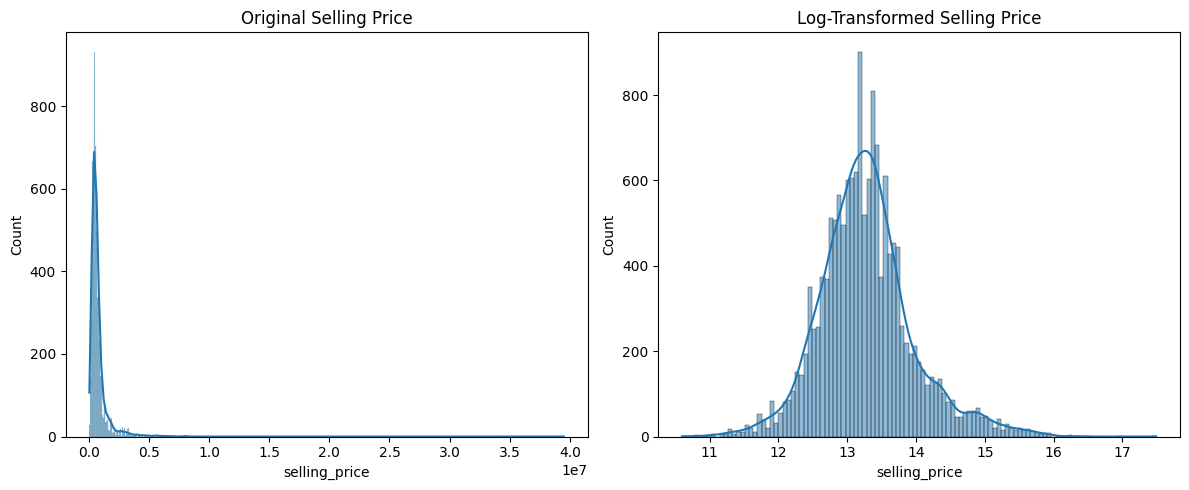

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["selling_price"], kde=True, ax=axes[0])
axes[0].set_title("Original Selling Price")

sns.histplot(np.log1p(df["selling_price"]), kde=True, ax=axes[1])
axes[1].set_title("Log-Transformed Selling Price")

plt.tight_layout()
plt.show()

In [ ]:
df["log_selling_price"] = np.log1p(df["selling_price"])

In [9]:
df[["selling_price", "log_selling_price"]].head()

,selling_price,log_selling_price
0,120000,11.695255
1,550000,13.217675
2,215000,12.278398
3,226000,12.328295
4,570000,13.253393


In [ ]:
X = df.drop(columns=["selling_price", "log_selling_price"])
y = df["log_selling_price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (15242, 12)
y shape: (15242,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (12193, 12)
Test set: (3049, 12)


In [12]:
categorical_features = [
    "brand",
    "model",
    "seller_type",
    "fuel_type",
    "transmission_type"
]

numerical_features = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats",
    "age_mileage"
]

In [13]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train[categorical_features])
X_test_cat = encoder.transform(X_test[categorical_features])

print("Encoded training shape:", X_train_cat.shape)
print("Encoded test shape:", X_test_cat.shape)

Encoded training shape: (12193, 154)
Encoded test shape: (3049, 154)


c:\Users\Rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
